In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train.shape ,x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation= 'relu' , input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation= 'relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9572 - loss: 0.1434 - val_accuracy: 0.9829 - val_loss: 0.0515
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9858 - loss: 0.0465 - val_accuracy: 0.9878 - val_loss: 0.0356
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9900 - loss: 0.0327 - val_accuracy: 0.9909 - val_loss: 0.0313
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9924 - loss: 0.0236 - val_accuracy: 0.9903 - val_loss: 0.0293
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9944 - loss: 0.0180 - val_accuracy: 0.9902 - val_loss: 0.0330


In [ ]:
model.save("/content/drive/MyDrive/models/cnn_mnist_model.keras")

In [ ]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/models/cnn_mnist_model.keras")

In [ ]:
history.history.items()

dict_items([('accuracy', [0.9572333097457886, 0.9858333468437195, 0.9899666905403137, 0.9923666715621948, 0.9944333434104919]), ('loss', [0.14337493479251862, 0.04646749794483185, 0.0327204130589962, 0.0235767662525177, 0.01797635108232498]), ('val_accuracy', [0.9829000234603882, 0.9878000020980835, 0.9908999800682068, 0.9902999997138977, 0.9901999831199646]), ('val_loss', [0.05151771381497383, 0.03555278107523918, 0.03126973658800125, 0.029261281713843346, 0.03296854346990585])])

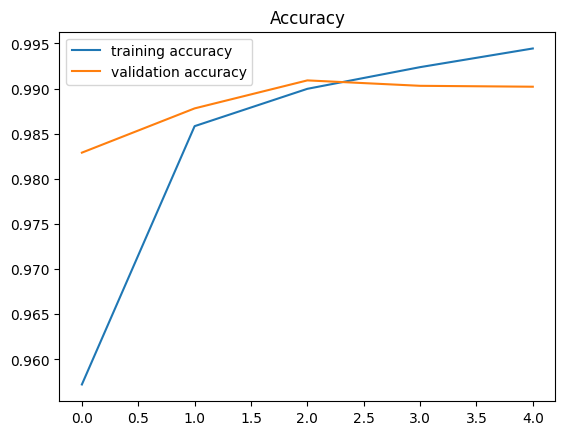

In [ ]:
plt.plot(history.history["accuracy"] , label = "training accuracy")
plt.plot(history.history["val_accuracy"] , label = "validation accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()



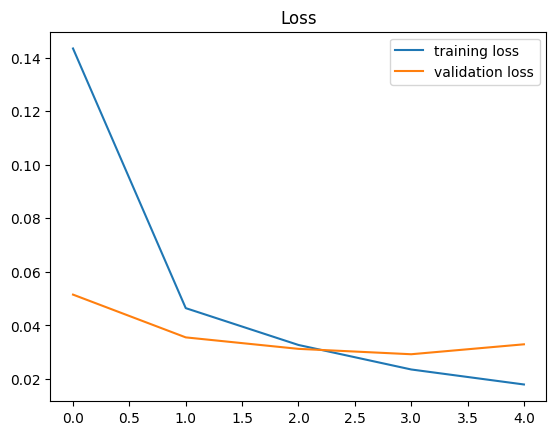

In [ ]:
plt.plot(history.history["loss"] , label = "training loss")
plt.plot(history.history["val_loss"] , label = "validation loss")
plt.title("Loss")
plt.legend()
plt.show()

In [ ]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/models/cnn_mnist_model.keras")

In [ ]:
img = Image.open("/content/drive/MyDrive/models/WhatsApp Image 2026-03-25 at 2.42.04 PM.jpeg")
img.size

(225, 225)

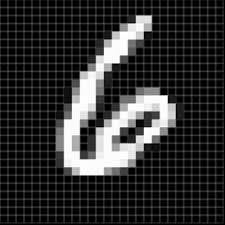

In [ ]:
img = Image.open("/content/drive/MyDrive/models/WhatsApp Image 2026-03-25 at 2.42.04 PM.jpeg").convert('L')
img

In [ ]:
img = img.resize((28,28))

In [ ]:
img

In [ ]:
img_array = np.array(img)
img_array = img_array / 255.0
img_array

array([[0.0627451 , 0.06666667, 0.06666667, 0.07058824, 0.07058824,
        0.06666667, 0.06666667, 0.06666667, 0.07058824, 0.0745098 ,
        0.07058824, 0.07058824, 0.07058824, 0.06666667, 0.07058824,
        0.06666667, 0.07058824, 0.05490196, 0.05882353, 0.06666667,
        0.07058824, 0.07058824, 0.07058824, 0.07058824, 0.07058824,
        0.07058824, 0.0745098 , 0.0627451 ],
       [0.0745098 , 0.07843137, 0.07843137, 0.08235294, 0.08235294,
        0.07843137, 0.07843137, 0.07843137, 0.08235294, 0.08235294,
        0.08235294, 0.07843137, 0.08235294, 0.07843137, 0.07843137,
        0.06666667, 0.08627451, 0.17254902, 0.16470588, 0.08235294,
        0.07843137, 0.07843137, 0.08235294, 0.08235294, 0.08235294,
        0.08235294, 0.08235294, 0.07058824],
       [0.07058824, 0.07843137, 0.0745098 , 0.07843137, 0.07843137,
        0.07843137, 0.0745098 , 0.07843137, 0.07843137, 0.07843137,
        0.07843137, 0.07843137, 0.07843137, 0.0745098 , 0.0745098 ,
        0.12941176, 0.3333

In [ ]:
img_array = img_array.reshape(1, 28, 28, 1)
img_array.shape

(1, 28, 28, 1)

In [ ]:
prediction = loaded_model.predict(img_array)
predicted_label = np.argmax(prediction)
print("Predicted Digit:" , predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step
Predicted Digit: 6


In [ ]:
prediction

array([[1.3227462e-09, 1.8590175e-12, 1.9611587e-13, 2.5063130e-13,
        1.0790726e-10, 9.6743404e-09, 1.0000000e+00, 2.2062498e-15,
        3.1716069e-10, 1.0553215e-13]], dtype=float32)